# DeepTraLog — 4 Model Comparison (Traces + Logs)

| Model | Type | Purpose |
|-------|------|---------|
| **M1** | Isolation Forest | Classical ML baseline — no deep learning |
| **M2** | GCN + SVDD | Graph baseline — graph structure without gating |
| **M3** | gnn + SVDD (mixed) | Ablation — shows normal-only training is critical |
| **M4** | gnn + SVDD (normal-only) | Full model — combines graph structure, gating and normal-only SVDD training for best precision and root cause localisation |

All models trained on TraceLogData with trace + log TEG graphs.


## Cell 1 — Imports & Config

In [1]:
import os, sys, json, math
sys.path.insert(0, '.')

import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve,
)
from model.deeptralog_model import DeepTraLogModel
from model.baselines import IsolationForestBaseline

# ── Paths ─────────────────────────────────────────────────────
GRAPH_DIR   = r'C:\Users\Anonymous\Downloads\DeepTraLog-main (1)\DeepTraLog-main\GraphData'
ALLLOG_PATH = r'C:\Users\Anonymous\Downloads\DeepTraLog-main (1)\DeepTraLog-main\TraceLogData\alllog\alllog.log'
GLOVE_PATH  = r'C:\Users\Anonymous\Downloads\glove\glove.6B.300d.txt'
RESULTS_DIR   = 'results'

# ── Config ────────────────────────────────────────────────────
NODE_FEAT_DIM     = 306   # GloVe 300-dim + 6 extra features
HIDDEN            = 64
LATENT            = 32
NUM_LAYERS        = 3
EPOCHS            = 30
BATCH_SIZE        = 32
LR                = 1e-4
LR_MIN            = 1e-6
WARMUP_EPOCHS     = 8
PATIENCE          = 8
N_THRESHOLDS      = 200
MAX_TRACES_NORMAL = None
MAX_TRACES_FAULT  = None

os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Node feature dim: {NODE_FEAT_DIM}')

all_results = {}

c:\Users\Anonymous\anaconda3\envs\advml-gpu-clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Node feature dim: 306


c:\Users\Anonymous\anaconda3\envs\advml-gpu-clean\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Cell 2 — Load Dataset (run once)

In [2]:
# ── Cell 2 — Load Dataset ONCE, build both loaders ────────────

from utils.dataset_with_logs import (
    GloVeEmbedder, DeepTraLogDatasetWithLogs
)
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset
import random, torch

random.seed(42)
torch.manual_seed(42)

# Step 1: Load GloVe ONCE
embedder = GloVeEmbedder(GLOVE_PATH)

# Step 2: Load dataset ONCE (GraphData + alllog)
print('\nLoading dataset...')
dataset = DeepTraLogDatasetWithLogs(
    graph_dir=GRAPH_DIR,
    alllog_path=ALLLOG_PATH,
    embedder=embedder,
    max_per_file=None,
)

# Step 3: Build splits
idx        = list(range(len(dataset)))
random.shuffle(idx)

normal_idx = [i for i in idx if dataset[i].y.item() == 0]
anom_idx   = [i for i in idx if dataset[i].y.item() == 1]

n_train = int(len(normal_idx) * 0.8)
n_val   = int(len(normal_idx) * 0.1)

# Normal-only split (M1, M2, M4)
train_idx_normal = normal_idx[:n_train]
val_idx   = (normal_idx[n_train:n_train+n_val]
             + anom_idx[:len(anom_idx)//2])
test_idx  = (normal_idx[n_train+n_val:]
             + anom_idx[len(anom_idx)//2:])

# Mixed split (M3) — same dataset, just different indices
t = int(len(idx) * 0.7)
train_idx_mixed = idx[:t]

# Step 4: Build loaders
train_loader_normal = DataLoader(
    Subset(dataset, train_idx_normal),
    batch_size=BATCH_SIZE, shuffle=True)
train_loader_mixed  = DataLoader(
    Subset(dataset, train_idx_mixed),
    batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(
    Subset(dataset, val_idx),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(
    Subset(dataset, test_idx),  batch_size=BATCH_SIZE)

n_normal = sum(1 for g in dataset if g.y.item() == 0)
n_anom   = sum(1 for g in dataset if g.y.item() == 1)
print(f'\nDataset ready')
print(f'Total:        {len(dataset)} (normal={n_normal}, anomalous={n_anom})')
print(f'Train normal: {len(train_idx_normal)}')
print(f'Train mixed:  {len(train_idx_mixed)}')
print(f'Val:          {len(val_idx)}')
print(f'Test:         {len(test_idx)}')
print(f'Graph size:   {dataset[0].x.shape}')

Loading GloVe from C:\Users\Anonymous\Downloads\glove\glove.6B.300d.txt...
Loaded 400,000 word vectors

Loading dataset...
Found 8 .jsons files
Pass 1: Collecting trace IDs...
Found 132,485 unique trace IDs

Loading alllog from C:\Users\Anonymous\Downloads\DeepTraLog-main (1)\DeepTraLog-main\TraceLogData\alllog\alllog.log...
  Filtering to 132,485 known traces + ERROR/WARN only
  Loaded 118,779 ERROR/WARN lines across 73,999 traces
  Skipped 7,581,956 INFO/DEBUG lines
  Skipped 4,315 unknown trace lines

Pass 2: Building TEG graphs...
  process0.jsons: 16559 graphs
  process1.jsons: 16561 graphs
  process2.jsons: 16561 graphs
  process3.jsons: 16561 graphs
  process4.jsons: 16561 graphs
  process5.jsons: 16561 graphs
  process6.jsons: 16561 graphs
  process7.jsons: 16560 graphs

Total: 132485 graphs (normal=109151, anomalous=23334)
Graphs with logs: 73999 (55.9%)
Node feature dim: 306

Dataset ready
Total:        132485 (normal=109151, anomalous=23334)
Train normal: 87320
Train mixed: 

In [3]:
# ── Check log match rate ───────────────────────────────────────
total        = len(dataset)
with_logs    = sum(1 for g in dataset 
                   if any(m['type'] == 'log' 
                          for m in g.node_meta))
without_logs = total - with_logs

print(f'\nLog match statistics:')
print(f'  Total traces:        {total:,}')
print(f'  Traces with logs:    {with_logs:,} ({with_logs/total*100:.1f}%)')
print(f'  Traces without logs: {without_logs:,} ({without_logs/total*100:.1f}%)')

# Also check normal vs anomalous match rate
normal_with_logs = sum(1 for g in dataset 
                       if g.y.item() == 0 and 
                       any(m['type'] == 'log' 
                           for m in g.node_meta))
anom_with_logs   = sum(1 for g in dataset 
                       if g.y.item() == 1 and 
                       any(m['type'] == 'log' 
                           for m in g.node_meta))

n_normal = sum(1 for g in dataset if g.y.item() == 0)
n_anom   = sum(1 for g in dataset if g.y.item() == 1)

print(f'\n  Normal with logs:    {normal_with_logs:,}/{n_normal:,} ({normal_with_logs/n_normal*100:.1f}%)')
print(f'  Anomalous with logs: {anom_with_logs:,}/{n_anom:,} ({anom_with_logs/n_anom*100:.1f}%)')

# Sample graph info
g0 = dataset[0]
n_span_nodes = sum(1 for m in g0.node_meta if m['type'] == 'span')
n_log_nodes  = sum(1 for m in g0.node_meta if m['type'] == 'log')
print(f'\nSample graph (trace 0):')
print(f'  Total nodes: {g0.x.shape[0]}')
print(f'  Span nodes:  {n_span_nodes}')
print(f'  Log nodes:   {n_log_nodes}')
print(f'  Node dim:    {g0.x.shape[1]}')
print(f'  Edges:       {g0.edge_index.shape[1]}')
print(f'  Label:       {"normal" if g0.y.item()==0 else "anomalous"}')


Log match statistics:
  Total traces:        132,485
  Traces with logs:    73,999 (55.9%)
  Traces without logs: 58,486 (44.1%)

  Normal with logs:    53,619/109,151 (49.1%)
  Anomalous with logs: 20,380/23,334 (87.3%)

Sample graph (trace 0):
  Total nodes: 58
  Span nodes:  50
  Log nodes:   8
  Node dim:    306
  Edges:       56
  Label:       normal


In [5]:
g = dataset[0]
print(g.x.shape)

torch.Size([58, 306])


0## Cell 3 — Helper Functions

In [6]:
def get_lr(epoch, warmup_epochs, total_epochs, lr_max, lr_min):
    if epoch < warmup_epochs:
        return lr_max * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
    cosine   = 0.5 * (1 + math.cos(math.pi * progress))
    return lr_min + (lr_max - lr_min) * cosine

def get_scores_gnn(model, loader):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            scores, _, _ = model(batch)
            all_scores.extend(scores.cpu().tolist())
            all_labels.extend(batch.y.cpu().tolist())
    return np.array(all_scores), np.array(all_labels)

def best_threshold_by_f1(scores, labels):
    """Find threshold that maximises F1 score."""
    candidates = np.linspace(scores.min(), scores.max(), N_THRESHOLDS)
    best_f1, best_thr = 0.0, candidates[0]
    for thr in candidates:
        preds = (scores > thr).astype(int)
        f1    = f1_score(labels, preds,
                         pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def compute_metrics(scores, labels, threshold=None):
    if threshold is None:
        threshold, _ = best_threshold_by_f1(scores, labels)
    preds  = (scores > threshold).astype(int)
    auc    = roc_auc_score(labels, scores) if len(set(labels)) > 1 else 0.5
    f1     = f1_score(labels, preds, pos_label=1, zero_division=0)
    prec   = precision_score(labels, preds, pos_label=1, zero_division=0)
    rec    = recall_score(labels, preds, pos_label=1, zero_division=0)
    fpr, tpr, _ = roc_curve(labels, scores)
    return {
        'auc': round(auc, 4), 'f1': round(f1, 4),
        'precision': round(prec, 4), 'recall': round(rec, 4),
        'threshold': float(threshold),
        'fpr': fpr.tolist(), 'tpr': tpr.tolist(),
    }

def train_gnn(model_type, train_loader, model_name,
              in_channels=NODE_FEAT_DIM):
    print(f'\n{"="*60}')
    print(f'  Training {model_name}')
    print(f'{"="*60}')

    model = DeepTraLogModel(
        in_channels=in_channels,
        hidden=HIDDEN, latent=LATENT,
        num_layers=NUM_LAYERS,
        model_type=model_type,
    ).to(device)
    optimiser = optim.Adam(
        model.parameters(), lr=LR, weight_decay=1e-5)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
    print('Initialising SVDD centre...')
    model.init_centre(train_loader, device)

    best_val_auc = 0.0
    best_epoch, no_improve = 0, 0
    history = []

    print(f"  {'Ep':>4}  {'Loss':>10}  {'AUC':>7}  "
          f"{'F1':>6}  {'Prec':>6}  {'Rec':>6}")
    print(f"  {'-'*4}  {'-'*10}  {'-'*7}  "
          f"{'-'*6}  {'-'*6}  {'-'*6}")

    for epoch in range(1, EPOCHS + 1):
        lr = get_lr(epoch-1, WARMUP_EPOCHS, EPOCHS, LR, LR_MIN)
        for g in optimiser.param_groups: g['lr'] = lr

        model.train()
        total_loss, n_graphs = 0.0, 0
        for batch in train_loader:
            batch = batch.to(device)
            optimiser.zero_grad()
            scores, _, _ = model(batch)
            loss = scores.mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            optimiser.step()
            total_loss += loss.item() * batch.num_graphs
            n_graphs   += batch.num_graphs
        train_loss = total_loss / n_graphs

        val_scores, val_labels = get_scores_gnn(model, val_loader)
        threshold, val_f1 = best_threshold_by_f1(
            val_scores, val_labels)
        val_preds = (val_scores > threshold).astype(int)
        auc  = roc_auc_score(val_labels, val_scores) \
               if len(set(val_labels)) > 1 else 0.5
        f1   = f1_score(val_labels, val_preds,
                        pos_label=1, zero_division=0)
        prec = precision_score(val_labels, val_preds, 
                       pos_label=1, zero_division=0)
        rec  = recall_score(val_labels, val_preds,
                            pos_label=1, zero_division=0)

        history.append({
            'epoch': epoch, 'loss': round(train_loss, 6),
            'auc': round(auc, 4), 'f1': round(f1, 4),
            'prec': round(prec, 4), 'rec': round(rec, 4)})


        marker = ''
        if auc > best_val_auc:
            best_val_auc  = auc
            best_epoch    = epoch
            no_improve    = 0
            marker        = '  ✅'
            torch.save({
                'model_state': model.state_dict(),
                'threshold':   float(threshold),
                'centre':      model.svdd.centre,
                'in_channels': in_channels,
                'hidden':      HIDDEN,
                'latent':      LATENT,
                'num_layers':  NUM_LAYERS,
                'model_type':  model_type,
            }, f'{RESULTS_DIR}/{model_name}.pt')
        else:
            no_improve += 1

        print(f"  {epoch:4d}  {train_loss:10.6f}  "
              f"{auc:7.3f}  {f1:6.3f}  "
              f"{prec:6.3f}  {rec:6.3f}{marker}")

        if no_improve >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

    # Test evaluation
    ckpt = torch.load(
        f'{RESULTS_DIR}/{model_name}.pt',
        map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.svdd.centre = ckpt['centre'].to(device)
    threshold = ckpt['threshold']
    test_scores, test_labels = get_scores_gnn(model, test_loader)
    metrics = compute_metrics(test_scores, test_labels, threshold)
    metrics['best_epoch'] = best_epoch
    metrics['history']    = history
    metrics['model_name'] = model_name

    print(f'\n  Best epoch: {best_epoch}  Val AUC={best_val_auc:.4f}')
    print(f'\n  Test AUC={metrics["auc"]:.4f}  '
          f'F1={metrics["f1"]:.4f}  '
          f'Prec={metrics["precision"]:.4f}  '
          f'Rec={metrics["recall"]:.4f}')

    with open(
        f'{RESULTS_DIR}/{model_name}_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)
    return metrics

print('Helper functions ready')

Helper functions ready


## Cell 4 — M1: Isolation Forest

In [7]:
print('='*60)
print('  M1: Isolation Forest')
print('='*60)

iso = IsolationForestBaseline(
    contamination=0.176, random_state=42)
iso.fit(train_loader_normal)

val_scores, val_labels = iso.score(val_loader)
threshold, _ = best_threshold_by_f1(val_scores, val_labels)

test_scores, test_labels = iso.score(test_loader)
metrics_m1 = compute_metrics(test_scores, test_labels, threshold)
metrics_m1['best_epoch'] = 0
metrics_m1['history']    = []
metrics_m1['model_name'] = 'M1_isolation_forest'

print(f'\nTest AUC={metrics_m1["auc"]:.4f}  '
      f'F1={metrics_m1["f1"]:.4f}  '
      f'Prec={metrics_m1["precision"]:.4f}  '
      f'Rec={metrics_m1["recall"]:.4f}')

with open(
    f'{RESULTS_DIR}/M1_isolation_forest_metrics.json', 'w') as f:
    json.dump(metrics_m1, f, indent=2)

all_results['M1'] = metrics_m1
print('Saved')

  M1: Isolation Forest
  Extracting features for Isolation Forest...
  Fitting on 87320 normal traces...

Test AUC=0.9173  F1=0.8801  Prec=0.9168  Rec=0.8461
Saved


## Cell 5 — M2: GCN Baseline (graph without gating)

In [8]:
all_results['M2'] = train_gnn(
    model_type='gcn',
    train_loader=train_loader_normal,
    model_name='M2_gcn',
)


  Training M2_gcn
Parameters: 40,609
Initialising SVDD centre...
  Centre initialised  norm=1.4661
    Ep        Loss      AUC      F1    Prec     Rec
  ----  ----------  -------  ------  ------  ------
     1    0.000348    0.727   0.688   0.664   0.713  ✅
     2    0.000022    0.851   0.773   0.679   0.898  ✅
     3    0.000033    0.795   0.742   0.766   0.719
     4    0.000009    0.570   0.681   0.517   1.000
     5    0.000009    0.732   0.700   0.774   0.639
     6    0.000010    0.784   0.761   0.762   0.760
     7    0.000008    0.667   0.681   0.517   1.000
     8    0.000007    0.628   0.681   0.517   1.000
     9    0.000004    0.483   0.681   0.517   1.000
    10    0.000004    0.792   0.726   0.848   0.634
  Early stopping at epoch 10

  Best epoch: 2  Val AUC=0.8509

  Test AUC=0.8535  F1=0.7716  Prec=0.6780  Rec=0.8953


## Cell 6 — M3: gnn Mixed Training (Ablation)

In [ ]:
all_results['M3'] = train_gnn(
    model_type='gnn',
    train_loader=train_loader_mixed,
    model_name='M3_ggnn_mixed',
)


  Training M3_ggnn_mixed
Parameters: 65,377
Initialising SVDD centre...
  Centre initialised  norm=1.4424
    Ep        Loss      AUC      F1    Prec     Rec
  ----  ----------  -------  ------  ------  ------
     1    0.000437    0.824   0.771   0.679   0.892  ✅
     2    0.000031    0.571   0.681   0.517   1.000
     3    0.000013    0.831   0.802   0.757   0.853  ✅
     4    0.000008    0.856   0.830   0.773   0.896  ✅
     5    0.000007    0.868   0.834   0.778   0.898  ✅
     6    0.000006    0.692   0.712   0.754   0.675
     7    0.000006    0.652   0.682   0.517   1.000
     8    0.000005    0.869   0.830   0.757   0.919  ✅
     9    0.000004    0.615   0.682   0.518   1.000
    10    0.000003    0.768   0.792   0.820   0.767
    11    0.000003    0.726   0.729   0.708   0.752
    12    0.000002    0.729   0.739   0.748   0.730
    13    0.000002    0.798   0.776   0.714   0.849
    14    0.000001    0.830   0.809   0.786   0.834
    15    0.000001    0.729   0.693   0.712   

## Cell 7 — M4: gnn Normal-only (Our Model)

In [ ]:
all_results['M4'] = train_gnn(
    model_type='gnn',
    train_loader=train_loader_normal,
    model_name='M4_ggnn_normal_only',
)


  Training M4_ggnn_normal_only
Parameters: 65,377
Initialising SVDD centre...
  Centre initialised  norm=1.2692
    Ep        Loss      AUC      F1    Prec     Rec
  ----  ----------  -------  ------  ------  ------
     1    0.000608    0.844   0.710   0.940   0.571  ✅
     2    0.000015    0.903   0.694   0.930   0.554  ✅
     3    0.000007    0.931   0.706   0.974   0.553  ✅
     4    0.000005    0.932   0.718   0.978   0.567  ✅
     5    0.000004    0.903   0.743   0.982   0.598
     6    0.000005    0.928   0.711   0.982   0.557
     7    0.000004    0.901   0.721   0.979   0.571
     8    0.000004    0.930   0.718   0.983   0.566
     9    0.000003    0.927   0.719   0.980   0.568
    10    0.000002    0.922   0.826   0.964   0.722
    11    0.000002    0.946   0.843   0.965   0.748  ✅
    12    0.000002    0.936   0.858   0.975   0.767
    13    0.000001    0.913   0.835   0.959   0.740
    14    0.000001    0.938   0.889   0.930   0.852
    15    0.000001    0.922   0.866   0.

## Cell 8 — Results Table & Comparison Graphs

  MODEL COMPARISON
  Model                              AUC      F1    Prec     Rec
  ------------------------------  ------  ------  ------  ------
  M1: Isolation Forest             0.917   0.880   0.917   0.846
  M2: GCN + SVDD                   0.854   0.772   0.678   0.895
  M3: GGNN mixed training          0.869   0.827   0.756   0.913
  M4: GGNN normal-only             0.947   0.845   0.968   0.749


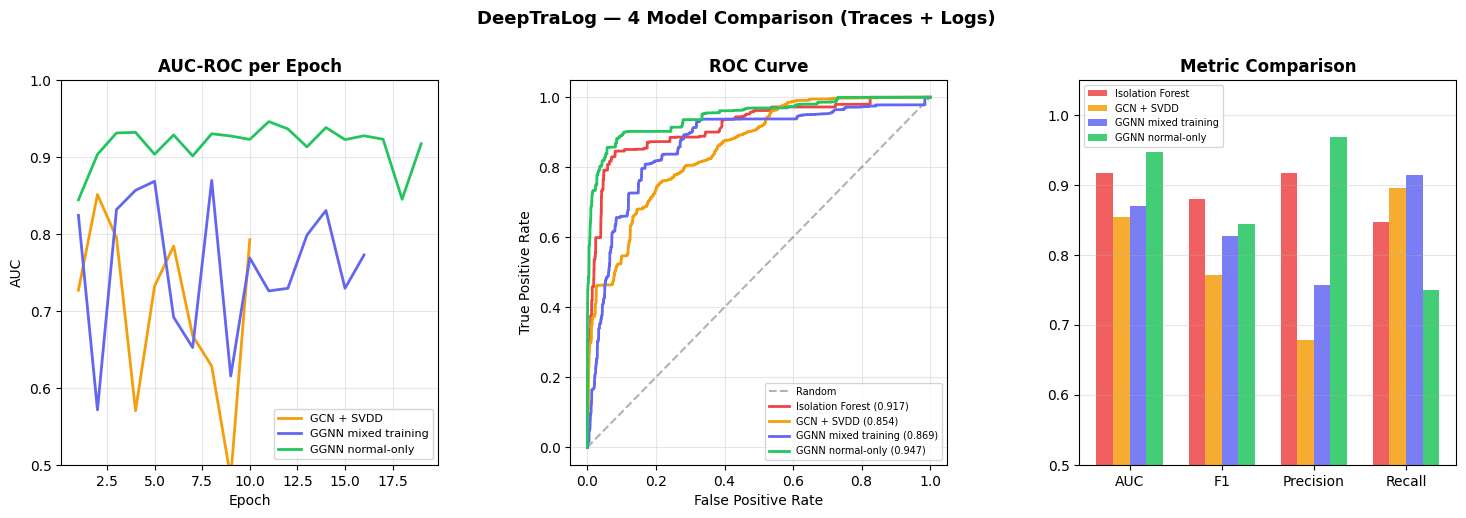

Saved → results/model_comparison.png


In [ ]:
print('='*72)
print('  MODEL COMPARISON')
print('='*72)
print(f"  {'Model':<30}  {'AUC':>6}  "
      f"{'F1':>6}  {'Prec':>6}  {'Rec':>6}")
print(f"  {'-'*30}  {'-'*6}  "
      f"{'-'*6}  {'-'*6}  {'-'*6}")

model_labels = {
    'M1': 'M1: Isolation Forest',
    'M2': 'M2: GCN + SVDD',
    'M3': 'M3: gnn mixed training',
    'M4': 'M4: gnn normal-only',
}
colors = {
    'M1': '#ef4444',
    'M2': '#f59e0b',
    'M3': '#6366f1',
    'M4': '#22c55e',
}

for key, label in model_labels.items():
    if key in all_results:
        r = all_results[key]
        print(f"  {label:<30}  {r['auc']:6.3f}  "
              f"{r['f1']:6.3f}  "
              f"{r['precision']:6.3f}  "
              f"{r['recall']:6.3f}")

print('='*72)

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
for key in ['M2', 'M3', 'M4']:
    if key in all_results and all_results[key]['history']:
        h = all_results[key]['history']
        ax1.plot(
            [e['epoch'] for e in h],
            [e['auc']   for e in h],
            color=colors[key],
            label=model_labels[key].split(':')[1].strip(),
            linewidth=2)
ax1.set_title('AUC-ROC per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('AUC')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_ylim(0.5, 1.0)

ax2 = fig.add_subplot(gs[1])
ax2.plot([0,1],[0,1],'k--',alpha=0.3,label='Random')
for key, label in model_labels.items():
    if key in all_results:
        r = all_results[key]
        ax2.plot(
            r['fpr'], r['tpr'],
            color=colors[key], linewidth=2,
            label=f"{label.split(':')[1].strip()} "
                  f"({r['auc']:.3f})")
ax2.set_title('ROC Curve', fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
metrics_names = ['AUC', 'F1', 'Precision', 'Recall']
x       = np.arange(len(metrics_names))
width   = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
for i, (key, label) in enumerate(model_labels.items()):
    if key in all_results:
        r    = all_results[key]
        vals = [r['auc'], r['f1'],
                r['precision'], r['recall']]
        ax3.bar(
            x + offsets[i]*width, vals, width,
            label=label.split(':')[1].strip(),
            color=colors[key], alpha=0.85)
ax3.set_title('Metric Comparison', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names)
ax3.set_ylim(0.5, 1.05)
ax3.legend(fontsize=7); ax3.grid(axis='y', alpha=0.3)

plt.suptitle(
    'DeepTraLog — 4 Model Comparison (Traces + Logs)',
    fontsize=13, fontweight='bold', y=1.02)
plt.savefig(
    f'{RESULTS_DIR}/model_comparison.png',
    dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/model_comparison.png')